In [2]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [3]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'

In [5]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=10).ds.elevation


In [6]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [7]:
extent =[100,160,-69,-65.2]
extent_meop =[138.5,143,-67,-66.4]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

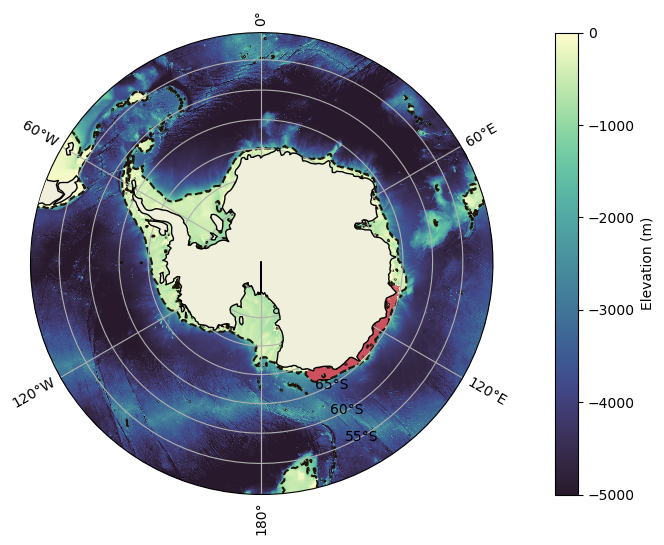

In [8]:

shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
shelf.plot_region()


In [9]:
meop=MEOP(extent=extent_meop)
meop.load_profiles(full=True)


  0%|          | 0/80 [00:00<?, ?it/s]

100%|██████████| 80/80 [00:47<00:00,  1.67it/s]


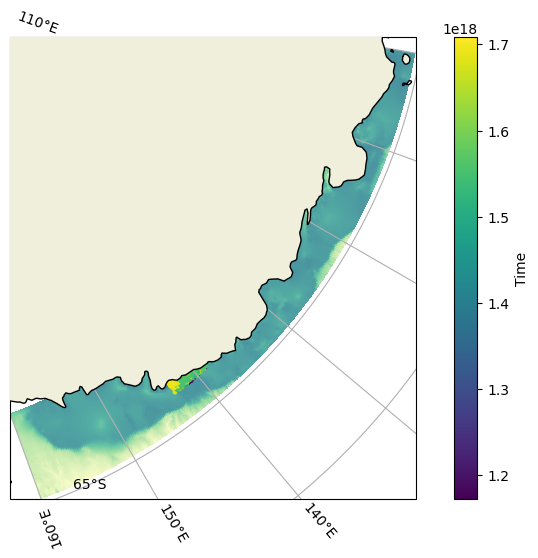

In [10]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax=ax,da=elevation,extent=extent,cmap=cmocean.cm.deep)
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


In [11]:
sla_shelf = shelf.crop_da(sla)

In [12]:
# COMPOSITE PLOT
# FIGURE CODE EHRE FOR NEATNESS
def composite_timeseries(ax,idx,idx_name,idx_positive,idx_negative,limit_label,bg1=None,bg_name='',ylim=[-12,12]):
    '''
    da1 = index timeseries which we are using to determine 
    '''
    if bg1 is not None:
        ax.plot(bg1.time,bg1,color='#96ae8d',label=bg_name)

    ax.plot(idx.time,idx,color='olive',label=idx_name)
    ax.plot(idx.time,np.zeros_like(idx),color='#373e02')
    ax.fill_between(idx.time, 0,ylim[1], where=idx_positive, alpha=0.4, facecolor='darkkhaki',label='+/- '+ limit_label)
    ax.fill_between(idx.time,ylim[0],0, where=idx_negative, alpha=0.4, facecolor='darkkhaki')
    ax.set_ylim(ylim)
    ax.set_ylabel(idx_name)
    ax.legend(loc='best')
    ax.set_title('(a)',loc='left')
    ax.grid()


def posneg_map(axs,idx_positive,idx_negative,idx_name,data,vmax):
    # extract data where positive and negative
    data_pos = data.where(idx_positive,drop=True).mean('time')
    data_neg = data.where(idx_negative,drop=True).mean('time')
    # plot pos and neg maps
    pfns.sp(axs[0],data_pos,extent=extent,cmap=cmocean.cm.balance,cbar='SHA (cm)',vmax=vmax,vmin=-vmax,cbar_orientation='vertical',land_zorder=3)#title='POSITIVE ' + idx_name + ', (> ' + fill_text + ')')
    pfns.sp(axs[1],data_neg,extent=extent,cmap=cmocean.cm.balance,cbar='SHA (cm)',vmax=vmax,vmin=-vmax,cbar_orientation='vertical',land_zorder=3)#title='NEGATIVE ' + idx_name + ', (< '+ lower_fill_text + ')'
    axs[0].set_title('(b)',loc='left')
    axs[1].set_title('(c)',loc='left')
    axs[0].text(130,-80,'+'+idx_name,transform=ccrs.PlateCarree(),size=15,c='#373e02',ha='center',bbox=dict(boxstyle="square",facecolor='darkkhaki',alpha=0.5))
    axs[1].text(130,-80,'-'+idx_name,transform=ccrs.PlateCarree(),size=15,c='#373e02',ha='center',bbox=dict(boxstyle="square",facecolor='darkkhaki',alpha=0.5))



In [13]:
# prepare profiles for ts plots
# in order to combine many profiles to create a transect, we need to interpolate them onto the same vertical grid
# create a pressure index using the most commonly occurring values for profiles
allpres = np.concatenate([p[0].pressure for p in meop.df.temperature])
values, counts = np.unique(allpres[~np.isnan(allpres)], return_counts=True)
pressure_df = pd.DataFrame(counts,values)
pressure_axis= pressure_df[(pressure_df>1000).to_numpy().transpose().flatten()].index.to_numpy()


In [14]:

# function to take a profile and turn it into a ds with uniform z-axis and tagged with the longitude
def reindex_profile(profile,longitude):
    return profile \
            .rename({'N_LEVELS':'pressure'}) \
            .dropna(dim='pressure',how='all') \
            .interp(coords={'pressure':pressure_axis}) \
            .assign_coords({'longitude':longitude}) \
            .expand_dims('longitude')

In [18]:
background_data = sla_shelf.mean(['latitude','longitude'])-sla_shelf.mean()
idx_data = background_data.rolling(time=12,center=True).mean('time')
limit = idx_data.std()
limit_label = r'$1\sigma$'

idx_positive = idx_data >= limit
idx_negative = idx_data <= -limit

In [19]:
# filter profiles
df_months = meop.df.index.to_period('M')

def get_posneg_ts(idx_in):
    months = pd.PeriodIndex(idx_in.time.where(idx_in,drop=True).values.astype('datetime64[M]'),freq='M')
    filtered_df = meop.df[df_months.isin(months)].dropna()
    filtered_temp = xr.merge([reindex_profile(p[0],l) for p,l in zip(filtered_df.temperature, filtered_df.longitude)]).TEMP_ADJUSTED
    filtered_psal = xr.merge([reindex_profile(p[0],l) for p,l in zip(filtered_df.salinity, filtered_df.longitude)]).PSAL_ADJUSTED
    return filtered_temp,filtered_psal

t_pos, s_pos = get_posneg_ts(idx_positive)
t_neg, s_neg = get_posneg_ts(idx_negative)


In [ ]:
# COMPOSITE PLOT


# SET UP FIGURE
fig = plt.figure(figsize=(10,18))
gs = fig.add_gridspec(9,4)

tlims = [-2.1,0.4]
slims = [32.9,34.9]

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

composite_timeseries(ax1,
                    idx_data,
                    'SLA',
                    idx_positive,
                    idx_negative,
                    limit_label,
                    bg1=background_data,
                    bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
posneg_map([ax2,ax3],idx_positive,idx_negative,'SLA SA',sanom(sla_shelf),10)

# FIG3: SLA MAP
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
posneg_map([ax4,ax5],idx_positive,idx_negative,'SICE SA',sanom(shelf.crop_da(sice)),0.4)

# FIG4: TS DENSITY CONTOUR
ax6 = fig.add_subplot(gs[5:7,0:2])
ax7 = fig.add_subplot(gs[5:7,2:4])
sns.kdeplot(ax=ax6,x=s_pos.values.flatten(), y=t_pos.values.flatten())
sns.kdeplot(ax=ax7,x=s_neg.values.flatten(), y=t_neg.values.flatten())
ax6.set_ylim(tlims)
ax6.set_xlim(slims)
ax7.set_ylim([-2.1,0.4])
ax7.set_xlim([32.9,34.9])

# FIG5: TS PROFILES
ax8 = fig.add_subplot(gs[7:9,0])
ax9 = fig.add_subplot(gs[7:9,1])
ax10 = fig.add_subplot(gs[7:9,2])
ax11 = fig.add_subplot(gs[7:9,3])

def plot_prof(ax,prof,xlabel,color,mean_color,lims):
    for lon in prof.longitude:
        ax.plot(prof.sel(longitude=lon),prof.pressure,color=color)
    ax.plot(prof.mean('longitude'),prof.pressure,color=mean_color)
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    ax.set_xlabel(xlabel)
    ax.set_xlim(lims)

plot_prof(ax8,t_pos,'Temperature','thistle','mediumvioletred',tlims)
plot_prof(ax9,s_pos,'Salinity','lightblue','steelblue',slims)
plot_prof(ax10,t_neg,'Temperature','thistle','mediumvioletred',tlims)
plot_prof(ax11,s_neg,'Salinity','lightblue','steelblue',slims)




fig.tight_layout()


